# OpenAI Image & Vision

https://platform.openai.com/docs/guides/images-vision?format=url

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from openai import OpenAI
import base64

client = OpenAI()

response = client.responses.create(
    model = 'gpt-6-astra',
    input = "Generate an image of gray tabby cat hugging an otter with an orange scarf",
    tools = [
        {
        'type': 'image_generation',
        'model': 'gpt-image-2.5-sunburst'
        }
    ]
)

image_data = [
    output.result
    for output in response.output
    if output.type == 'image_generation_call'
]

if image_data:
    image_base64 = image_data[0]

    with open("otter.png", "wb") as f:
        f.write(base64.b64decode(image_base64))

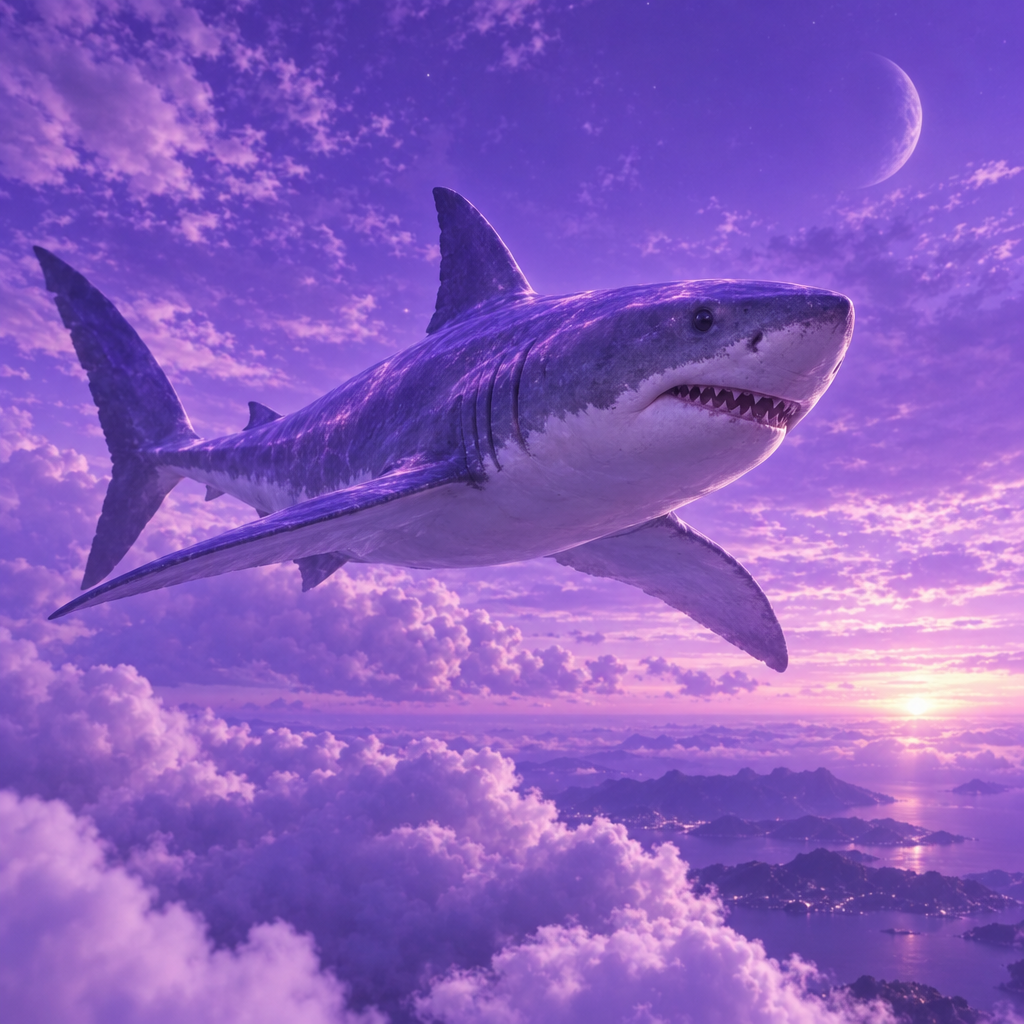

In [ ]:
from io import BytesIO # bytes 데이터를 파일처럼 조작
from PIL import Image
from IPython.display import display # 주피터 노트북 환경에서 각종 출력

def generate_image(prompt: str):
    response = client.images.generate(
        model = 'gpt-image-2.5-flare',
        prompt = prompt,
        size = "1024x1024",
        quality = 'high',
        output_format = 'png'
    )

    b64 = response.data[0].b64_json # 생성된 이미지의 base64 문자열
    img_bytes = base64.b64decode(b64) # base64 이미지 -> bytes 변환

    img = Image.open(BytesIO(img_bytes)) # bytes 데이터를 이미지로 열기
    display(img) # display 출력

generate_image('보랏빛 하늘을 날아다니는 상어')